<a href="https://colab.research.google.com/github/redwanhasan980/deep-learning/blob/main/perceptron_mnist_digit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Single Layer Perceptron for Handwritten Digit Recognition

## Dataset: MNIST

The model is implemented **from scratch** using NumPy.

## 1. What is the problem?

We want the computer to look at a handwritten digit image and predict which digit it is.

Possible classes are:

$$0, 1, 2, 3, 4, 5, 6, 7, 8, 9$$

Each MNIST image is grayscale and has size:

$$28 \times 28$$

So each image has:

$$28 \times 28 = 784$$

pixel values.

The model will take these 784 pixel values as input and produce 10 output scores, one score for each digit class.

## 2. Theory: Single Layer Perceptron

A perceptron is one of the simplest neural network models.

For one input sample, the model calculates:

$$z = XW + b$$

Where:

- $X$ = input features
- $W$ = weights
- $b$ = bias
- $z$ = raw output scores, also called logits

For MNIST:

- Input size = 784
- Output classes = 10
- Weight matrix shape = $784 \times 10$
- Bias shape = $10$

There is **no hidden layer** in this model.

So the structure is:

```text
28×28 image → Flatten to 784 values → Single output layer with 10 neurons → Predicted digit
```

Because this is a multi-class classification problem, we use a **softmax output**. This is often called a **single-layer softmax perceptron** or **single-layer neural classifier**.

## 3. Theory: Softmax Function

The model first produces raw scores called logits:

$$z_0, z_1, z_2, ..., z_9$$

These scores are not probabilities. To convert them into probabilities, we use softmax:

$$P(y=i) = \frac{e^{z_i}}{\sum_{j=0}^{9} e^{z_j}}$$

Softmax makes sure that:

- Every output value is between 0 and 1
- All output values add up to 1

The class with the highest probability becomes the final prediction.

Example:

```text
[0.01, 0.02, 0.90, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
```

Here, the highest probability is for class `2`, so the model predicts digit `2`.

## 4. Theory: Loss Function
## Loss Function: Categorical Cross-Entropy

To train the model, we need a way to measure **how wrong the model prediction is**. This measurement is called the **loss**.

For multi class classification, such as digit recognition from **0 to 9**, we use **categorical cross-entropy loss**.

The model gives a probability for each digit class. For example, for one image, the model may predict:

```text
Digit 0: 0.02
Digit 1: 0.01
Digit 2: 0.04
Digit 3: 0.90
Digit 4: 0.01
Digit 5: 0.01
Digit 6: 0.00
Digit 7: 0.00
Digit 8: 0.01
Digit 9: 0.00
```

Here, the model is saying that the image is most likely digit **3**, because digit 3 has the highest probability.

For one sample, the loss is calculated as:

$$
Loss = -\log(P_{correct})
$$

Where:

* $P_{correct}$ means the predicted probability of the true class
* $\log$ means logarithm
* The negative sign makes the loss positive

### Easy Explanation

If the actual digit is **3**, and the model gives digit 3 a high probability like **0.90**, then the loss will be small.

That means the model made a good prediction.

But if the actual digit is **3**, and the model gives digit 3 a low probability like **0.05**, then the loss will be large.

That means the model made a bad prediction.

So, cross-entropy loss punishes the model when it gives low probability to the correct answer.

### Simple Example

If the correct class probability is high:

$$
Loss = -\log(0.90)
$$

The loss will be small.

If the correct class probability is low:

$$
Loss = -\log(0.05)
$$

The loss will be large.

### Main Idea

The goal of training is to reduce this loss.

During training, the model updates its weights again and again so that the probability of the correct digit becomes higher.

So we can say:

```text
Higher probability for correct class → Lower loss → Better model
Lower probability for correct class → Higher loss → Worse model
```


## 5. Theory: Gradient Descent

The model learns by updating its **weights** and **bias**.

The basic idea of gradient descent is:

1. Make a prediction
2. Calculate the loss
3. Calculate gradients
4. Update weights and bias in the opposite direction of the gradient

The update rule is:

$$
W = W - \alpha \frac{\partial Loss}{\partial W}
$$

$$
b = b - \alpha \frac{\partial Loss}{\partial b}
$$

Where:

* $\alpha$ is the learning rate
* $\frac{\partial Loss}{\partial W}$ is the gradient for weights
* $\frac{\partial Loss}{\partial b}$ is the gradient for bias

---

### Why Do We Use Mini-Batch Gradient Descent?

In this notebook, we use **mini-batch gradient descent**.

That means we do not update the model using only **one image at a time**.
We also do not use the **whole dataset at once**.

Instead, we update the model using a small group of images, called a **mini-batch**.

For example, if the batch size is 128, the model looks at 128 images, calculates the average error, and then updates the weights.

---

### Why Not Use One Image at a Time?

If we update the model using only one image at a time, the training can become unstable.

One image may be very different from another image.

For example:

* One handwritten digit may be very clear
* Another digit may be messy
* Another digit may be tilted or difficult to read

So, if the model updates after every single image, the weight updates may move in many different directions.

This can make the training path noisy.

```text
Single image update → Fast but noisy learning
```

---

### Why Mini-Batch Is Better

Mini-batch gradient descent uses a small group of images together.

This gives a more balanced idea of the error.

So the model does not react too strongly to one unusual image.

It also trains faster than using the full dataset at once.

```text
Mini-batch update → More stable and faster learning
```

---

### Simple Example

Suppose we have 60,000 training images.

If we use one image at a time:

```text
60,000 updates in one epoch
```

This can be very noisy.

If we use a mini-batch size of 128:

```text
60,000 ÷ 128 ≈ 469 updates in one epoch
```

This is more efficient and stable.

---

### Main Idea

Mini-batch gradient descent is a good balance between speed and stability.

```text
One image at a time → noisy but frequent updates
Whole dataset at once → stable but slow updates
Mini-batch → balanced, faster, and stable updates
```

That is why mini-batch gradient descent is commonly used in machine learning and neural network training.


## 6. Import Required Packages

We are not using TensorFlow, Keras, PyTorch, or scikit-learn.

The dataset will be downloaded using Python's built-in "urllib" library.

<!-- import gzip

This imports the gzip module. It is used to read compressed .gz files.
MNIST files are often stored in compressed .gz format.

import struct

This imports the struct module. It is used to read binary data.
MNIST IDX files are stored in binary format, so struct helps read information like number of images, rows, and columns.


np.random.seed(42)

This fixes the random number generation.

The model starts with random weights. Without setting a seed, every time we run the notebook, the random weights may be different.

So the result may change slightly every time.

Using:

np.random.seed(42)

helps us get the same random numbers each time we run the notebook. -->

In [ ]:
import os
import gzip
import struct
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 7. Download MNIST Dataset

MNIST is stored in a special binary file format called **IDX format**.

The files are compressed using `.gz`.

We will download four files:

1. Training images
2. Training labels
3. Testing images
4. Testing labels

Then we will manually read those files using Python.

<!--  ## Dataset Download Code Explanation

This code creates a folder for the MNIST dataset, downloads the dataset files from the internet, and stores the file paths so that we can load them later.

```python
DATA_DIR = Path("mnist_data")
```

This line creates a path object called `DATA_DIR`.

Here, the folder name is:

```text
mnist_data
```

This folder will be used to store the MNIST dataset files.

---

```python
DATA_DIR.mkdir(exist_ok=True)
```

This line creates the folder `mnist_data`.

The argument:

```python
exist_ok=True
```

means that if the folder already exists, Python will not show an error.

So this line is safe to run multiple times.

---

```python
MNIST_URLS = {
    "train_images": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
    "train_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
    "test_images": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz",
}
```

This dictionary stores the download links for the four MNIST dataset files.

The four files are:

```text
train_images → images used for training
train_labels → correct answers for training images
test_images  → images used for testing
test_labels  → correct answers for testing images
```

Each file is in `.gz` format, which means the files are compressed.

---

```python
file_paths = {}
```

This creates an empty dictionary.

Later, we will store the local file path of each downloaded file inside this dictionary.

For example, after downloading, it may contain something like:

```text
train_images → mnist_data/train-images-idx3-ubyte.gz
train_labels → mnist_data/train-labels-idx1-ubyte.gz
```

---

```python
for name, url in MNIST_URLS.items():
```

This loop goes through each item in the `MNIST_URLS` dictionary.

For each file:

* `name` stores the file type, such as `train_images`
* `url` stores the download link

---

```python
file_name = url.split("/")[-1]
```

This line extracts the actual file name from the URL.

For example, from this URL:

```text
https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz
```

It extracts:

```text
train-images-idx3-ubyte.gz
```

The `split("/")` separates the URL by `/`.

The `[-1]` takes the last part, which is the file name.

---

```python
file_path = DATA_DIR / file_name
```

This creates the full path where the file will be saved.

For example:

```text
mnist_data/train-images-idx3-ubyte.gz
```

So the file will be stored inside the `mnist_data` folder.

---

```python
file_paths[name] = file_path
```

This stores the file path in the `file_paths` dictionary.

This is useful because later we can easily access the file path using the file type name.

Example:

```python
file_paths["train_images"]
```

This will give the path of the training image file.

---

```python
if not file_path.exists():
```

This checks whether the file already exists or not.

If the file does not exist, then it will be downloaded.

---

```python
print(f"Downloading {file_name}...")
```

This prints a message showing which file is being downloaded.

Example:

```text
Downloading train-images-idx3-ubyte.gz...
```

---

```python
urllib.request.urlretrieve(url, file_path)
```

This line downloads the file from the given URL and saves it to the selected file path.

For example, it downloads the training image file and saves it inside the `mnist_data` folder.

---

```python
else:
    print(f"Already downloaded: {file_name}")
```

If the file already exists, then the code does not download it again.

Instead, it prints a message saying that the file is already downloaded.

This saves time because we do not need to download the same file again.

---

```python
print("\nAll dataset files are ready.")
```

After checking and downloading all four files, this line prints a final message.

The `\n` adds a blank line before the message.

---

## Main Idea

This code makes sure that all MNIST dataset files are available before training the model.

It does three main things:

```text
1. Creates a folder for the dataset
2. Downloads MNIST files if they are missing
3. Saves the file paths for later use
```

After this code runs, the dataset files are ready to be loaded and used for training the Single Layer Perceptron.

---

## Important Note

This code downloads MNIST using direct URLs.

If we use KaggleHub instead, then this direct download code is not needed.

For KaggleHub, we can use:

```python
import kagglehub

path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Path to dataset files:", path)
```

Then we read the files from the Kaggle download folder.
-->

In [ ]:
DATA_DIR = Path("mnist_data")
DATA_DIR.mkdir(exist_ok=True)

MNIST_URLS = {
    "train_images": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
    "train_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
    "test_images": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz",
}

file_paths = {}

for name, url in MNIST_URLS.items():
    file_name = url.split("/")[-1]
    file_path = DATA_DIR / file_name
    file_paths[name] = file_path

    if not file_path.exists():
        print(f"Downloading {file_name}...")
        urllib.request.urlretrieve(url, file_path)
    else:
        print(f"Already downloaded: {file_name}")

print("\nAll dataset files are ready.")

Already downloaded: train-images-idx3-ubyte.gz
Already downloaded: train-labels-idx1-ubyte.gz
Already downloaded: t10k-images-idx3-ubyte.gz
Already downloaded: t10k-labels-idx1-ubyte.gz

All dataset files are ready.


## 8. Read IDX Image and Label Files

The MNIST image file contains:

- Magic number
- Number of images
- Number of rows
- Number of columns
- Pixel data

The MNIST label file contains:

- Magic number
- Number of labels
- Label data

We will manually decode these files.

In [ ]:
def load_idx_images(path):
    with gzip.open(path, "rb") as file:
        magic, number_of_images, rows, cols = struct.unpack(">IIII", file.read(16))
        image_data = np.frombuffer(file.read(), dtype=np.uint8)
        images = image_data.reshape(number_of_images, rows, cols)
    return images


def load_idx_labels(path):
    with gzip.open(path, "rb") as file:
        magic, number_of_labels = struct.unpack(">II", file.read(8))
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    return labels


x_train_raw = load_idx_images(file_paths["train_images"])
y_train_raw = load_idx_labels(file_paths["train_labels"])
x_test_raw = load_idx_images(file_paths["test_images"])
y_test = load_idx_labels(file_paths["test_labels"])

print("Training images shape:", x_train_raw.shape)
print("Training labels shape:", y_train_raw.shape)
print("Testing images shape:", x_test_raw.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


## 9. Visualize Some Handwritten Digits

Before training a model, it is always good to look at the data.

Each image is a handwritten digit.

The label tells us the correct answer.

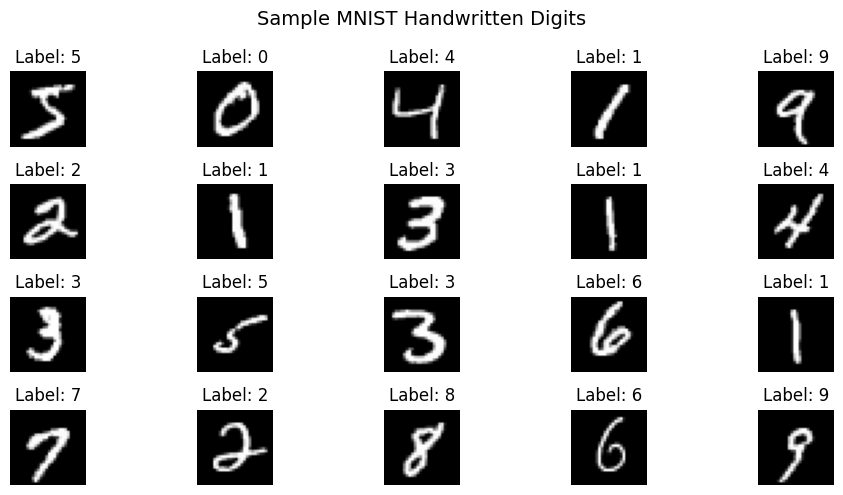

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap="gray")
    plt.title(f"Label: {y_train_raw[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Handwritten Digits", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Class Distribution

Now we check how many images are available for each digit.

A balanced dataset should have a similar number of samples for each class.

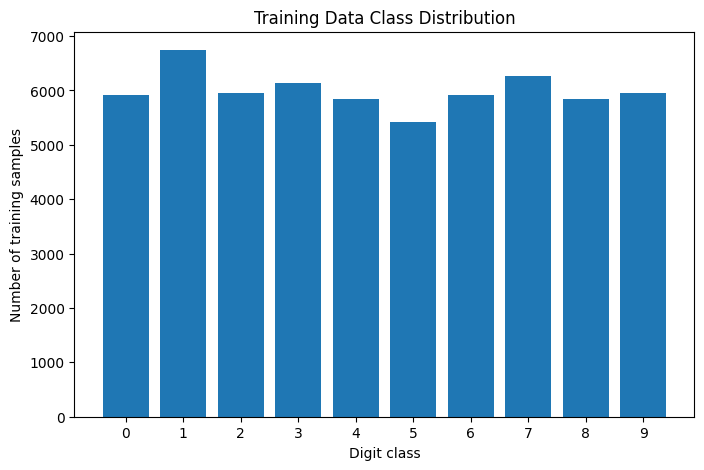

,Digit,Training Samples
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


In [ ]:
class_counts = pd.Series(y_train_raw).value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Digit class")
plt.ylabel("Number of training samples")
plt.title("Training Data Class Distribution")
plt.show()

class_distribution_table = pd.DataFrame({
    "Digit": class_counts.index,
    "Training Samples": class_counts.values
})

class_distribution_table

## 11. Preprocess the Data

The original pixel values are from 0 to 255.

We divide them by 255 so that the values become between 0 and 1.

This is called **normalization**.

Why normalization is useful:

- It makes training more stable
- It helps gradient descent work better
- It prevents large pixel values from making updates too large

We also flatten each image:

$$28 \times 28 \rightarrow 784$$

In [ ]:
# Normalize pixel values
x_train_normalized = x_train_raw.astype(np.float32) / 255.0
x_test_normalized = x_test_raw.astype(np.float32) / 255.0

# Flatten 28x28 images into 784 input features
x_train_flat = x_train_normalized.reshape(x_train_normalized.shape[0], -1)
x_test = x_test_normalized.reshape(x_test_normalized.shape[0], -1)

print("Flattened training shape:", x_train_flat.shape)
print("Flattened testing shape:", x_test.shape)

Flattened training shape: (60000, 784)
Flattened testing shape: (10000, 784)


## 12. Create Training and Validation Sets

We will split the original training data into:

- Training set: used to update the model
- Validation set: used to check performance during training

The test set will be used only at the end for final evaluation.

In [ ]:
number_of_samples = x_train_flat.shape[0]
indices = np.arange(number_of_samples)
np.random.shuffle(indices)

x_train_flat = x_train_flat[indices]
y_train_raw = y_train_raw[indices]

validation_size = 10000

x_val = x_train_flat[:validation_size]
y_val = y_train_raw[:validation_size]

x_train = x_train_flat[validation_size:]
y_train = y_train_raw[validation_size:]

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

Training set: (50000, 784) (50000,)
Validation set: (10000, 784) (10000,)
Test set: (10000, 784) (10000,)


## 13. One-Hot Encoding

The labels are currently single numbers.

Example:

```text
7
```

For cross-entropy training, it is easier to convert labels into one-hot vectors.

Example for digit 7:

```text
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
```

Only the correct class position contains `1`.

In [ ]:
def one_hot_encode(labels, number_of_classes=10):
    encoded = np.zeros((labels.shape[0], number_of_classes), dtype=np.float32)
    encoded[np.arange(labels.shape[0]), labels] = 1.0
    return encoded


y_train_one_hot = one_hot_encode(y_train, 10)
y_val_one_hot = one_hot_encode(y_val, 10)
y_test_one_hot = one_hot_encode(y_test, 10)

print("Example label:", y_train[0])
print("One-hot form:", y_train_one_hot[0])

Example label: 8
One-hot form: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


## 14. Define Softmax Function

Softmax converts raw model scores into probabilities.

To avoid numerical problems, we subtract the maximum score before applying exponential.

This does not change the final probability meaning, but it makes the calculation safer.

In [ ]:
def softmax(logits):
    shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_values = np.exp(shifted_logits)
    probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
    return probabilities

## 15. Define the Single Layer Perceptron Model

The model contains only:

- Weight matrix `W`
- Bias vector `b`

There is no hidden layer.

Forward calculation:

$$logits = XW + b$$

Then:

$$probabilities = softmax(logits)$$

In [ ]:
input_size = 784
number_of_classes = 10

# Small random weight initialization
W = np.random.randn(input_size, number_of_classes) * 0.01
b = np.zeros((1, number_of_classes))

print("Weight matrix shape:", W.shape)
print("Bias shape:", b.shape)

Weight matrix shape: (784, 10)
Bias shape: (1, 10)


## 16. Define Loss and Accuracy Functions

### Cross-Entropy Loss

For each sample, we take the probability of the correct class.

Then the loss is:

$$Loss = -\log(P_{correct})$$

### Accuracy

Accuracy means:

$$Accuracy = \frac{Correct\ Predictions}{Total\ Predictions}$$

In [ ]:
def cross_entropy_loss(probabilities, y_true_one_hot):
    epsilon = 1e-12
    probabilities = np.clip(probabilities, epsilon, 1.0 - epsilon)
    loss = -np.mean(np.sum(y_true_one_hot * np.log(probabilities), axis=1))
    return loss


def predict(X, W, b):
    logits = np.dot(X, W) + b
    probabilities = softmax(logits)
    predictions = np.argmax(probabilities, axis=1)
    return predictions


def calculate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

## 17. Train the Model Using Mini-Batch Gradient Descent

For each batch:

1. Calculate logits
2. Apply softmax
3. Calculate loss
4. Calculate gradients
5. Update weights and bias

Gradient formulas:

$$dZ = \frac{P - Y}{m}$$

$$dW = X^T dZ$$

$$db = \sum dZ$$

Where:

- $P$ = predicted probabilities
- $Y$ = true one-hot labels
- $m$ = batch size

In [ ]:
learning_rate = 0.1
epochs = 20
batch_size = 128

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

for epoch in range(epochs):
    permutation = np.random.permutation(x_train.shape[0])
    x_train_shuffled = x_train[permutation]
    y_train_shuffled = y_train[permutation]
    y_train_one_hot_shuffled = y_train_one_hot[permutation]

    for start in range(0, x_train.shape[0], batch_size):
        end = start + batch_size
        X_batch = x_train_shuffled[start:end]
        y_batch = y_train_one_hot_shuffled[start:end]

        # Forward pass
        logits = np.dot(X_batch, W) + b
        probabilities = softmax(logits)

        # Gradients
        m = X_batch.shape[0]
        dZ = (probabilities - y_batch) / m
        dW = np.dot(X_batch.T, dZ)
        db = np.sum(dZ, axis=0, keepdims=True)

        # Update parameters
        W = W - learning_rate * dW
        b = b - learning_rate * db

    # Calculate training performance after each epoch
    train_logits = np.dot(x_train, W) + b
    train_probabilities = softmax(train_logits)
    train_loss = cross_entropy_loss(train_probabilities, y_train_one_hot)
    train_predictions = np.argmax(train_probabilities, axis=1)
    train_accuracy = calculate_accuracy(y_train, train_predictions)

    # Calculate validation performance after each epoch
    val_logits = np.dot(x_val, W) + b
    val_probabilities = softmax(val_logits)
    val_loss = cross_entropy_loss(val_probabilities, y_val_one_hot)
    val_predictions = np.argmax(val_probabilities, axis=1)
    val_accuracy = calculate_accuracy(y_val, val_predictions)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 01/20 | Train Loss: 0.4165 | Train Accuracy: 0.8904 | Val Loss: 0.4144 | Val Accuracy: 0.8889
Epoch 02/20 | Train Loss: 0.3629 | Train Accuracy: 0.9003 | Val Loss: 0.3612 | Val Accuracy: 0.9002
Epoch 03/20 | Train Loss: 0.3406 | Train Accuracy: 0.9052 | Val Loss: 0.3387 | Val Accuracy: 0.9050
Epoch 04/20 | Train Loss: 0.3259 | Train Accuracy: 0.9090 | Val Loss: 0.3246 | Val Accuracy: 0.9099
Epoch 05/20 | Train Loss: 0.3164 | Train Accuracy: 0.9120 | Val Loss: 0.3158 | Val Accuracy: 0.9106
Epoch 06/20 | Train Loss: 0.3094 | Train Accuracy: 0.9144 | Val Loss: 0.3101 | Val Accuracy: 0.9118
Epoch 07/20 | Train Loss: 0.3042 | Train Accuracy: 0.9152 | Val Loss: 0.3053 | Val Accuracy: 0.9131
Epoch 08/20 | Train Loss: 0.2989 | Train Accuracy: 0.9175 | Val Loss: 0.3012 | Val Accuracy: 0.9158
Epoch 09/20 | Train Loss: 0.2950 | Train Accuracy: 0.9188 | Val Loss: 0.2975 | Val Accuracy: 0.9169
Epoch 10/20 | Train Loss: 0.2922 | Train Accuracy: 0.9193 | Val Loss: 0.2958 | Val Accuracy: 0.9172


## 18. Visualize Training Progress

We will plot:

1. Training loss vs validation loss
2. Training accuracy vs validation accuracy

A good model should show:

- Loss decreasing over time
- Accuracy increasing over time

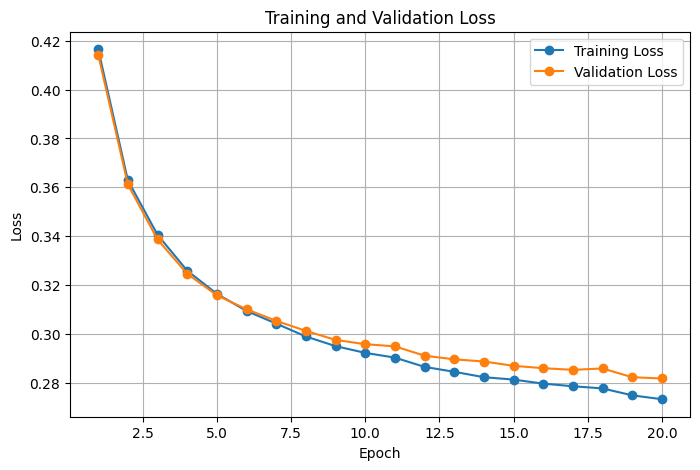

In [ ]:
epoch_numbers = np.arange(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, history["train_loss"], marker="o", label="Training Loss")
plt.plot(epoch_numbers, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

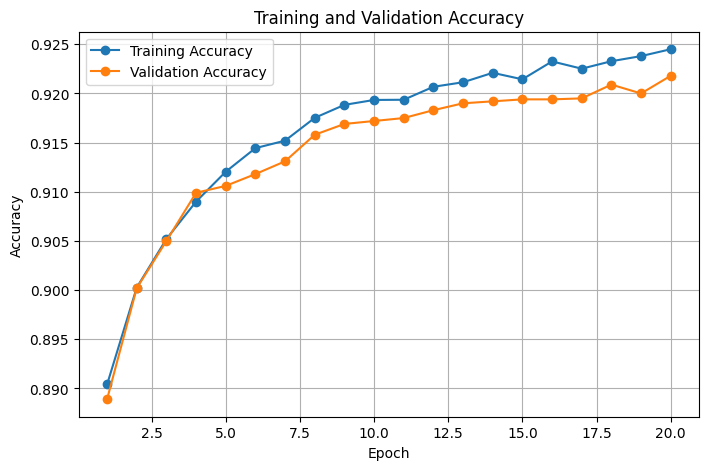

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, history["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(epoch_numbers, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 19. Final Test Accuracy

The test set was not used during training.

So it gives a better idea of how well the model performs on unseen handwritten digits.

In [ ]:
test_logits = np.dot(x_test, W) + b
test_probabilities = softmax(test_logits)
y_pred = np.argmax(test_probabilities, axis=1)

test_accuracy = calculate_accuracy(y_test, y_pred)

print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Accuracy Percentage: {test_accuracy * 100:.2f}%")

Final Test Accuracy: 0.9229
Final Test Accuracy Percentage: 92.29%


## 20. Theory: Confusion Matrix

A confusion matrix shows how many samples were correctly and incorrectly classified.

Rows represent the **actual class**.

Columns represent the **predicted class**.

Example:

- Row 5 and column 5 means actual digit 5 was predicted as digit 5.
- Row 5 and column 3 means actual digit 5 was wrongly predicted as digit 3.

The diagonal values are correct predictions.

The off-diagonal values are mistakes.

In [ ]:
def create_confusion_matrix(y_true, y_pred, number_of_classes=10):
    matrix = np.zeros((number_of_classes, number_of_classes), dtype=int)

    for actual, predicted in zip(y_true, y_pred):
        matrix[actual, predicted] += 1

    return matrix


confusion_matrix = create_confusion_matrix(y_test, y_pred, 10)

confusion_matrix_df = pd.DataFrame(
    confusion_matrix,
    index=[f"Actual {i}" for i in range(10)],
    columns=[f"Predicted {i}" for i in range(10)]
)

confusion_matrix_df

,Predicted 0,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5,Predicted 6,Predicted 7,Predicted 8,Predicted 9
Actual 0,959,0,3,2,0,5,8,1,2,0
Actual 1,0,1109,2,2,0,2,4,2,14,0
Actual 2,4,8,926,15,9,5,14,11,34,6
Actual 3,3,1,24,916,0,25,2,10,20,9
Actual 4,1,2,4,1,920,0,10,2,8,34
Actual 5,9,3,4,34,9,780,15,5,26,7
Actual 6,9,3,4,2,9,17,910,3,1,0
Actual 7,2,9,25,7,6,1,0,943,2,33
Actual 8,7,8,8,24,9,30,9,10,864,5
Actual 9,10,8,2,10,35,8,0,26,8,902


## 21. Visualize Confusion Matrix Using Matplotlib

This heatmap makes it easier to see where the model is making mistakes.

Darker cells mean larger values.

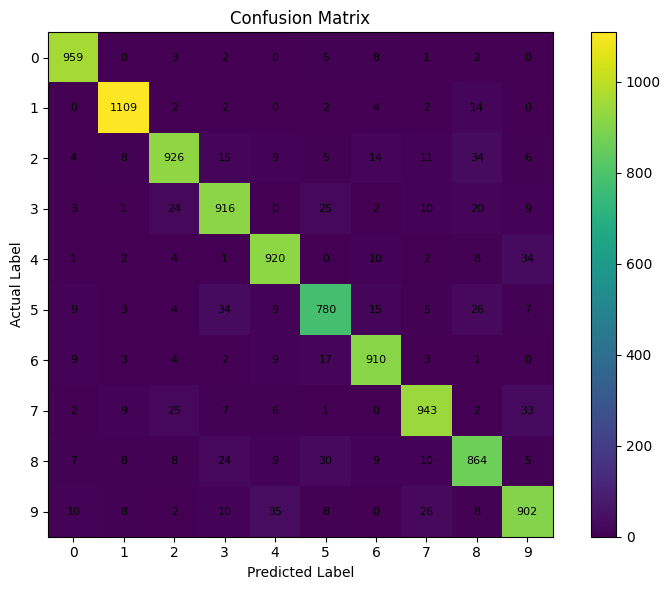

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

classes = np.arange(10)
plt.xticks(classes, classes)
plt.yticks(classes, classes)

for i in range(10):
    for j in range(10):
        plt.text(j, i, confusion_matrix[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 22. Theory: Precision, Recall, and F1-Score

Accuracy alone is not always enough.

So we also calculate:

### Precision

Precision tells us:

> When the model predicts a class, how often is it correct?

$$Precision = \frac{TP}{TP + FP}$$

### Recall

Recall tells us:

> Out of all actual samples of a class, how many did the model correctly find?

$$Recall = \frac{TP}{TP + FN}$$

### F1-Score

F1-score combines precision and recall into one value.

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

Where:

- TP = True Positive
- FP = False Positive
- FN = False Negative

For multi-class classification, we calculate these values separately for each digit class.

In [ ]:
def calculate_classification_metrics(confusion_matrix):
    true_positive = np.diag(confusion_matrix)
    false_positive = np.sum(confusion_matrix, axis=0) - true_positive
    false_negative = np.sum(confusion_matrix, axis=1) - true_positive
    support = np.sum(confusion_matrix, axis=1)

    precision = np.divide(
        true_positive,
        true_positive + false_positive,
        out=np.zeros_like(true_positive, dtype=float),
        where=(true_positive + false_positive) != 0
    )

    recall = np.divide(
        true_positive,
        true_positive + false_negative,
        out=np.zeros_like(true_positive, dtype=float),
        where=(true_positive + false_negative) != 0
    )

    f1_score = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision, dtype=float),
        where=(precision + recall) != 0
    )

    metrics_table = pd.DataFrame({
        "Class": np.arange(len(confusion_matrix)),
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1_score,
        "Support": support
    })

    accuracy = np.sum(true_positive) / np.sum(confusion_matrix)
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1_score)

    weighted_precision = np.sum(precision * support) / np.sum(support)
    weighted_recall = np.sum(recall * support) / np.sum(support)
    weighted_f1 = np.sum(f1_score * support) / np.sum(support)

    summary_table = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1-Score",
            "Weighted Precision",
            "Weighted Recall",
            "Weighted F1-Score"
        ],
        "Score": [
            accuracy,
            macro_precision,
            macro_recall,
            macro_f1,
            weighted_precision,
            weighted_recall,
            weighted_f1
        ]
    })

    return metrics_table, summary_table


metrics_table, summary_table = calculate_classification_metrics(confusion_matrix)

metrics_table

,Class,Precision,Recall,F1-Score,Support
0,0,0.955179,0.978571,0.966734,980
1,1,0.963510,0.977093,0.970254,1135
2,2,0.924152,0.897287,0.910521,1032
3,3,0.904245,0.906931,0.905586,1010
4,4,0.922768,0.936864,0.929763,982
5,5,0.893471,0.874439,0.883853,892
6,6,0.936214,0.949896,0.943005,958
7,7,0.930898,0.917315,0.924057,1028
8,8,0.882533,0.887064,0.884793,974
9,9,0.905622,0.893954,0.899751,1009


In [ ]:
summary_table

,Metric,Score
0,Accuracy,0.922900
1,Macro Precision,0.921859
2,Macro Recall,0.921941
3,Macro F1-Score,0.921831
4,Weighted Precision,0.922702
5,Weighted Recall,0.922900
6,Weighted F1-Score,0.922733


## 23. Visualize Precision, Recall, and F1-Score

This chart compares the model performance for each digit class.

If one class has low recall, it means the model misses many actual samples of that digit.

If one class has low precision, it means the model incorrectly predicts that digit too often.

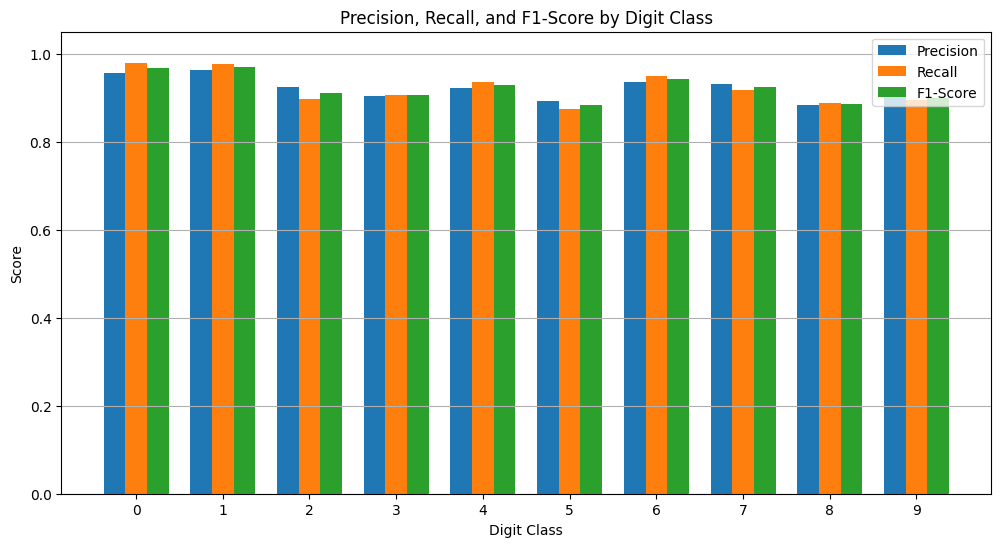

In [ ]:
classes = metrics_table["Class"].astype(str)
bar_width = 0.25
x_positions = np.arange(len(classes))

plt.figure(figsize=(12, 6))
plt.bar(x_positions - bar_width, metrics_table["Precision"], width=bar_width, label="Precision")
plt.bar(x_positions, metrics_table["Recall"], width=bar_width, label="Recall")
plt.bar(x_positions + bar_width, metrics_table["F1-Score"], width=bar_width, label="F1-Score")

plt.xlabel("Digit Class")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-Score by Digit Class")
plt.xticks(x_positions, classes)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y")
plt.show()

## 24. Show Correct and Incorrect Predictions

Now we will visualize some model predictions.

Green titles mean correct predictions.

Red titles mean wrong predictions.

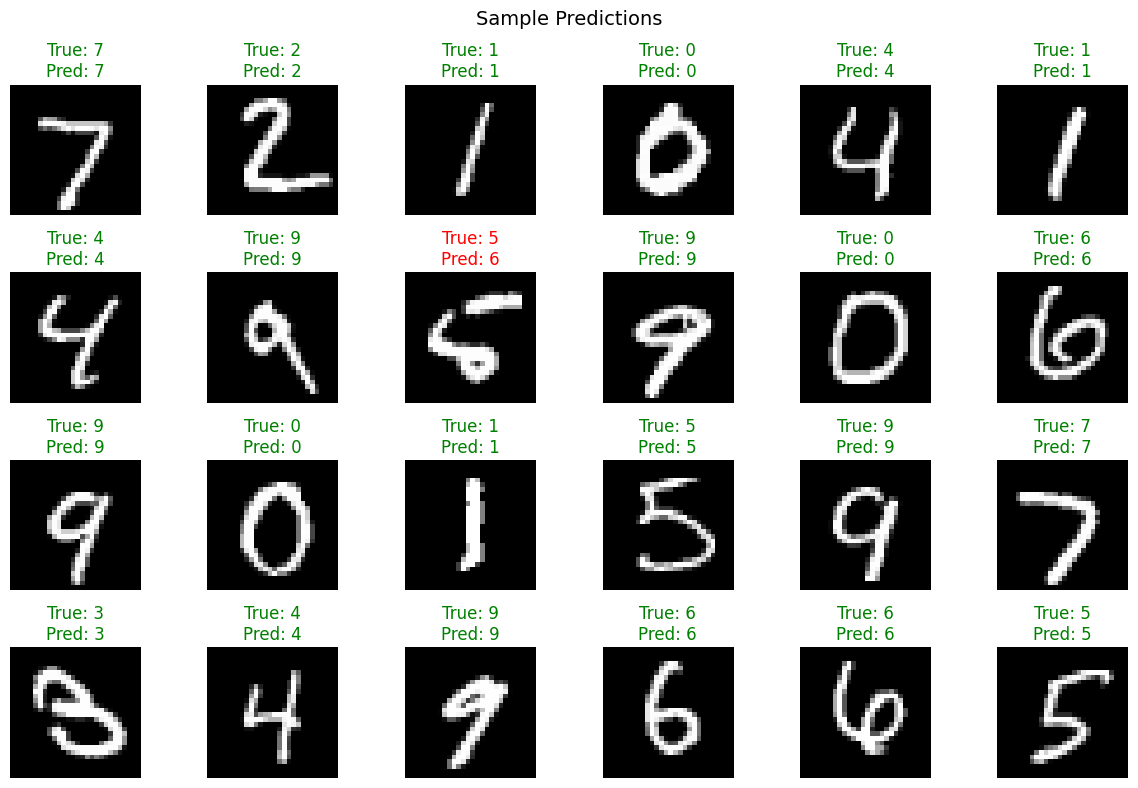

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(24):
    plt.subplot(4, 6, i + 1)
    plt.imshow(x_test_raw[i], cmap="gray")

    actual = y_test[i]
    predicted = y_pred[i]
    title_color = "green" if actual == predicted else "red"

    plt.title(f"True: {actual}\nPred: {predicted}", color=title_color)
    plt.axis("off")

plt.suptitle("Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()

## 25. Visualize Only Wrong Predictions

This helps us understand where the model is confused.

Since this is a single-layer model, it may confuse digits with similar shapes, such as:

- 3 and 5
- 4 and 9
- 7 and 9
- 8 and 9

Number of wrong predictions: 771


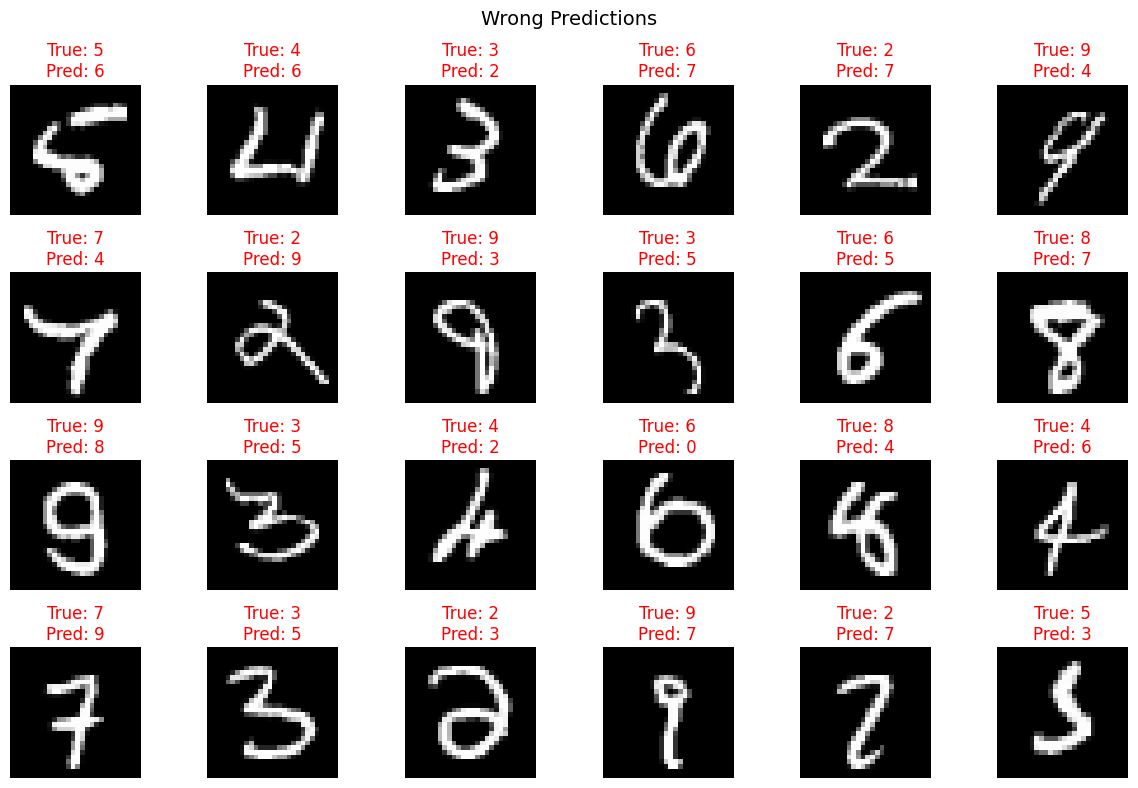

In [ ]:
wrong_indices = np.where(y_test != y_pred)[0]

print("Number of wrong predictions:", len(wrong_indices))

plt.figure(figsize=(12, 8))

for plot_index, image_index in enumerate(wrong_indices[:24]):
    plt.subplot(4, 6, plot_index + 1)
    plt.imshow(x_test_raw[image_index], cmap="gray")
    plt.title(f"True: {y_test[image_index]}\nPred: {y_pred[image_index]}", color="red")
    plt.axis("off")

plt.suptitle("Wrong Predictions", fontsize=14)
plt.tight_layout()
plt.show()

## 26. Make Prediction for One Image

Here we select one image from the test set and show the predicted probability for all 10 digits.

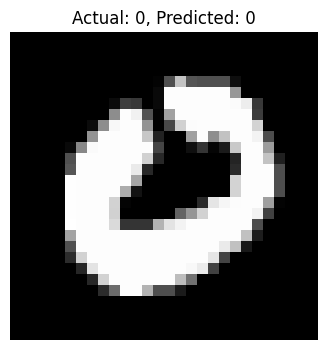

,Digit,Predicted Probability
0,0,9.999075e-01
1,1,2.296708e-16
2,2,2.189943e-07
3,3,5.219455e-11
4,4,4.799766e-09
5,5,6.723640e-05
6,6,2.334245e-05
7,7,3.400774e-10
8,8,1.705388e-06
9,9,3.995507e-10


In [ ]:
image_index = 25

single_image = x_test[image_index:image_index + 1]
single_logits = np.dot(single_image, W) + b
single_probabilities = softmax(single_logits)[0]
single_prediction = np.argmax(single_probabilities)

plt.figure(figsize=(4, 4))
plt.imshow(x_test_raw[image_index], cmap="gray")
plt.title(f"Actual: {y_test[image_index]}, Predicted: {single_prediction}")
plt.axis("off")
plt.show()

probability_table = pd.DataFrame({
    "Digit": np.arange(10),
    "Predicted Probability": single_probabilities
})

probability_table

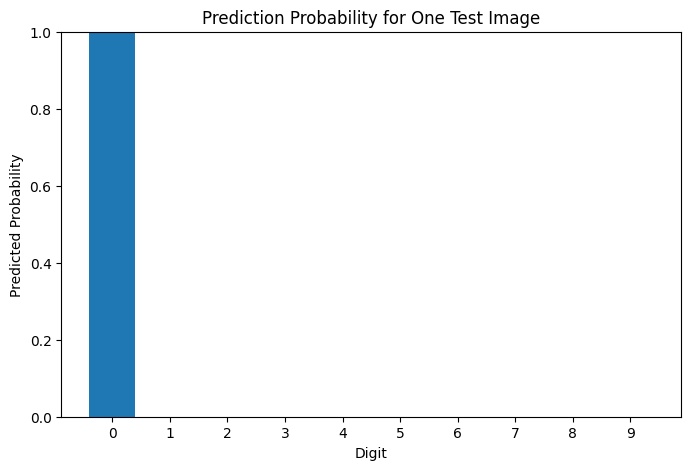

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(np.arange(10).astype(str), single_probabilities)
plt.xlabel("Digit")
plt.ylabel("Predicted Probability")
plt.title("Prediction Probability for One Test Image")
plt.ylim(0, 1)
plt.show()

## 27. Final Discussion

This notebook implemented a **Single Layer Perceptron** for handwritten digit recognition using the MNIST dataset.

The full model was written from scratch using NumPy.

### What we did

1. Downloaded MNIST without TensorFlow
2. Loaded IDX files manually
3. Normalized image pixel values
4. Flattened images into 784 input features
5. Built a single-layer model
6. Used softmax for multi-class classification
7. Trained using mini-batch gradient descent
8. Evaluated using accuracy, confusion matrix, precision, recall, and F1-score
9. Visualized training performance and predictions

### Why the result is good but not perfect

A single-layer perceptron is a linear classifier. It can learn simple decision boundaries, but handwritten digits are complex.

So the model can perform reasonably well, but it usually cannot beat deeper neural networks or CNNs.

### Main limitation

The model has no hidden layer, so it cannot automatically learn complex image features such as curves, strokes, edges, or shapes.

### Conclusion

A Single Layer Perceptron can recognize handwritten digits from MNIST, but its performance is limited compared to deep learning models. Still, it is very useful for understanding the basic theory of neural networks, classification, softmax, cross-entropy, and gradient descent.